## 1. Load data

In [1]:
import sys
import os

sys.path.append("D:\\kltn\\code\\src")
from data import load_data
from gpr import load_gpr, align_gpr_returns, build_states

In [77]:
prices, returns = load_data()
returns.head()

Ticker,VTI,IWM,AGG,LQD,MUB,DBC,GLD
Date,,,,,,,
2010-01-05,0.003831,-0.003445,0.004539,0.004765,0.001069,0.001188,-0.000911
2010-01-06,0.001390,-0.000942,-0.000578,-0.002951,-0.001458,0.017651,0.016365
2010-01-07,0.004157,0.007351,-0.001157,0.001239,0.001166,-0.012520,-0.006207
2010-01-08,0.003279,0.005440,0.000578,0.002187,0.000195,-0.000788,0.004951
2010-01-11,0.001378,-0.004038,-0.000772,0.001045,0.000000,-0.003157,0.013201


## 2. GPR

In [3]:
import pandas as pd

df = pd.read_excel("D:/kltn/code/data/gpr.xlsx")

# chuẩn hóa tên cột
df.columns = df.columns.str.strip()

# đổi tên về format chuẩn
df = df.rename(columns={
    "date": "Date",
    "GPRD": "GPR"
})

# convert datetime
df["Date"] = pd.to_datetime(df["Date"])

# giữ đúng 2 cột
df = df[["Date", "GPR"]]

# sort + clean
df = df.sort_values("Date").dropna()

# save
df.to_csv("D:/kltn/code/data/gpr.csv", index=False)

print(df.head())

        Date         GPR
0 1985-01-01  230.039429
1 1985-01-02  115.676971
2 1985-01-03   97.428459
3 1985-01-04  157.366638
4 1985-01-05   81.361313


## 3. Build Scenario

In [137]:
from scenario import (
    estimate_transition_matrix,
    cluster_returns,
    build_scenario_tree,
    assign_returns,
    cluster_returns_3
)


ImportError: cannot import name 'cluster_returns_3' from 'scenario' (D:\kltn\code\src\scenario.py)

In [78]:
gpr = load_gpr("D:\\kltn\\code\\data\\gpr.csv")

returns, gpr = align_gpr_returns(returns, gpr)

states = build_states(gpr)

print(states.value_counts())

W    1239
C    1203
N    1203
Name: count, dtype: int64


Transition matrix

In [6]:
P = estimate_transition_matrix(states)
print(P)

          N         C         W
N  0.491272  0.355777  0.152951
C  0.347465  0.383209  0.269327
W  0.156704  0.253635  0.589661


In [7]:
P.sum(axis=1)

N    1.0
C    1.0
W    1.0
dtype: float64

Cluster returns

In [ ]:
cluster_centers = cluster_returns_3(returns, n_clusters=3, random_state=42)
# cluster_centers = cluster_returns(returns, n_clusters=3)

print(cluster_centers.shape)  # (3, N)
print(cluster_centers)

TypeError: cluster_returns_2() missing 1 required positional argument: 'states'

Build scenario tree

In [9]:
tree = build_scenario_tree(P, cluster_centers, T=5)

for t, layer in enumerate(tree):
    print(f"Stage {t}: {layer[:5]}")

Stage 0: [('N', 1.0)]
Stage 1: [('N', np.float64(0.4912718204488778)), ('C', np.float64(0.3557772236076476)), ('W', np.float64(0.15295095594347466))]
Stage 2: [('N', np.float64(0.2413480015671544)), ('C', np.float64(0.17478332431597648)), ('W', np.float64(0.0751404945657469)), ('N', np.float64(0.1236200161828734)), ('C', np.float64(0.13633690779977184))]
Stage 3: [('N', np.float64(0.11856747209159456)), ('C', np.float64(0.08586612192081637)), ('W', np.float64(0.03691440755474349)), ('N', np.float64(0.06073103039407995)), ('C', np.float64(0.06697848088916472))]
Stage 4: [('N', np.float64(0.05824885786045917)), ('C', np.float64(0.04218360603092475)), ('W', np.float64(0.01813500820021064)), ('N', np.float64(0.029835443859435783)), ('C', np.float64(0.03290464023732032))]
Stage 5: [('N', np.float64(0.028616022440175703)), ('C', np.float64(0.020723616927910662)), ('W', np.float64(0.008909218492372807)), ('N', np.float64(0.014657312818725309)), ('C', np.float64(0.016165122510603747))]


Assign returns

In [10]:
node_returns = assign_returns(tree, cluster_centers)

print(node_returns[1][:3])  # check layer 1

[array([0.00371721, 0.00505867, 0.00102143, 0.0016786 , 0.00082516,
       0.00409393, 0.00340121]), array([-0.00194501, -0.00389129, -0.00079356, -0.00116424, -0.00047805,
       -0.00370693, -0.00293863]), array([-0.12082239, -0.14233512, -0.04083259, -0.05132482, -0.06347915,
       -0.08277767, -0.09190507])]


Map → return scenarios

In [106]:
import numpy as np

def sample_scenarios(P, T=5, n_samples=200):
    states = ["N", "C", "W"]
    scenarios = []

    for _ in range(n_samples):
        s = ["N"]  # start state

        for _ in range(T):
            current = s[-1]
            next_state = np.random.choice(
                states,
                p=P.loc[current].values
            )
            s.append(next_state)

        scenarios.append(s[1:])  # bỏ state đầu

    return scenarios


# ===== RUN =====
paths = sample_scenarios(P, T=5, n_samples=200)

mapping = {"N": 0, "C": 1, "W": 2}

scenario_returns = [
    [cluster_centers[mapping[s]] for s in seq]
    for seq in paths
]
# Lưu historical returns theo state

# returns_with_state = returns.copy()

# returns_with_state["state"] = states.values

# scenario_returns = []

# for seq in paths:

#     one_path = []

#     for state in seq:

#         sample_return = (
#             returns_with_state[
#                 returns_with_state["state"]
#                 == state
#             ]
#             .drop(
#                 columns="state"
#             )
#             .sample(
#                 n=1,
#                 replace=True
#             )
#             .values[0]
#         )

#         one_path.append(
#             sample_return
#         )

#     scenario_returns.append(
#         one_path
#     )

# scenario_returns = np.array(
#     scenario_returns
# )

In [107]:
print(scenario_returns[0])  # check scenario đầu tiên

[array([0.00371721, 0.00505867, 0.00102143, 0.0016786 , 0.00082516,
       0.00409393, 0.00340121]), array([0.00371721, 0.00505867, 0.00102143, 0.0016786 , 0.00082516,
       0.00409393, 0.00340121]), array([-0.12082239, -0.14233512, -0.04083259, -0.05132482, -0.06347915,
       -0.08277767, -0.09190507]), array([-0.12082239, -0.14233512, -0.04083259, -0.05132482, -0.06347915,
       -0.08277767, -0.09190507]), array([-0.00194501, -0.00389129, -0.00079356, -0.00116424, -0.00047805,
       -0.00370693, -0.00293863])]


Convert thành scenario paths

In [108]:
scenario_probs = []

for seq in paths:
    prob = 1.0
    prev = "N"

    for s in seq:
        prob *= P.loc[prev, s]
        prev = s

    scenario_probs.append(prob)

# chuẩn hóa 
scenario_probs = np.array(scenario_probs)
scenario_probs = scenario_probs / scenario_probs.sum()

In [109]:
print(len(scenario_returns))  # = 200
print(len(scenario_probs))    # = 200
print(scenario_probs.sum())   # ≈ 1.0
print(scenario_probs[:5])  # in ra xác suất của 5 kịch bản đầu tiên

200
200
1.0
[0.00339294 0.0046139  0.01758644 0.00334137 0.01758644]


Visualize

In [16]:
# 1. In ra chuỗi trạng thái của 5 kịch bản đầu tiên
print("=== 5 KỊCH BẢN TRẠNG THÁI ĐẦU TIÊN (PATHS) ===")
for i, path in enumerate(paths[:5]):
    print(f"Kịch bản {i+1}: {' -> '.join(path)}")

print("\n" + "="*50 + "\n")

# 2. In ra xác suất tương ứng của 5 kịch bản đó
print("=== XÁC SUẤT CỦA 5 KỊCH BẢN ĐẦU TIÊN ===")
for i, prob in enumerate(scenario_probs[:5]):
    # In dưới dạng phần trăm cho dễ đọc
    print(f"Xác suất kịch bản {i+1}: {prob*100:.4f}%")

print("\n" + "="*50 + "\n")

# 3. In ra cấu trúc lợi nhuận của kịch bản đầu tiên (để kiểm tra mapping)
print("=== LỢI NHUẬN CHI TIẾT CỦA KỊCH BẢN 1 (Tài sản đầu tiên - VTI) ===")
# scenario_returns[0] là list gồm 5 giai đoạn, mỗi giai đoạn là vector 7 tài sản
for t, returns in enumerate(scenario_returns[0]):
    print(f"Giai đoạn {t+1} (Trạng thái {paths[0][t]}): Lợi nhuận VTI = {returns[0]:.6f}")

=== 5 KỊCH BẢN TRẠNG THÁI ĐẦU TIÊN (PATHS) ===
Kịch bản 1: C -> W -> W -> C -> C
Kịch bản 2: C -> N -> N -> C -> N
Kịch bản 3: N -> W -> W -> W -> W
Kịch bản 4: C -> N -> N -> N -> N
Kịch bản 5: C -> C -> W -> W -> W


=== XÁC SUẤT CỦA 5 KỊCH BẢN ĐẦU TIÊN ===
Xác suất kịch bản 1: 0.3145%
Xác suất kịch bản 2: 0.4300%
Xác suất kịch bản 3: 0.8823%
Xác suất kịch bản 4: 0.8395%
Xác suất kịch bản 5: 0.7312%


=== LỢI NHUẬN CHI TIẾT CỦA KỊCH BẢN 1 (Tài sản đầu tiên - VTI) ===
Giai đoạn 1 (Trạng thái C): Lợi nhuận VTI = -0.001945
Giai đoạn 2 (Trạng thái W): Lợi nhuận VTI = -0.120822
Giai đoạn 3 (Trạng thái W): Lợi nhuận VTI = -0.120822
Giai đoạn 4 (Trạng thái C): Lợi nhuận VTI = -0.001945
Giai đoạn 5 (Trạng thái C): Lợi nhuận VTI = -0.001945


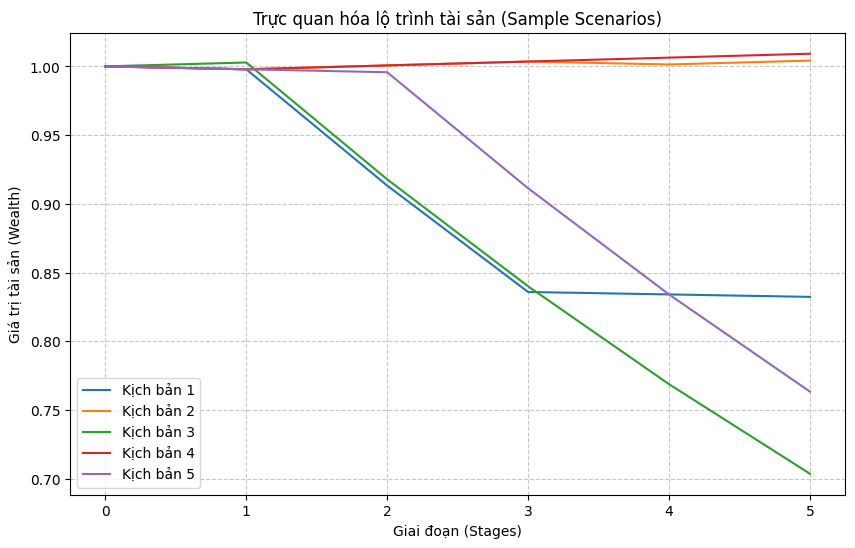

In [17]:

import matplotlib.pyplot as plt
import numpy as np

# Giả sử chúng ta muốn vẽ 5 kịch bản đầu tiên để kiểm tra
plt.figure(figsize=(10, 6))

for i in range(5):
    # Lấy dữ liệu của kịch bản thứ i
    # Cấu trúc: [vector_giai_doan_1, ..., vector_giai_doan_5]
    seq = scenario_returns[i] 
    
    # Chuyển đổi list các vector thành mảng numpy để dễ tính toán (T, N)
    returns_matrix = np.array(seq) 
    
    # Tính lợi nhuận trung bình của danh mục tại mỗi bước thời gian trong kịch bản này
    # (Hoặc bạn có thể chọn 1 tài sản cụ thể để vẽ, ví dụ tài sản đầu tiên: returns_matrix[:, 0])
    portfolio_path = np.mean(returns_matrix, axis=1) 
    
    # Tính giá trị tài sản tích lũy (bắt đầu từ 1.0)
    cumulative_path = np.cumprod(1 + portfolio_path)
    cumulative_path = np.insert(cumulative_path, 0, 1.0) # Thêm điểm gốc t=0
    
    plt.plot(cumulative_path, label=f"Kịch bản {i+1}")

plt.title("Trực quan hóa lộ trình tài sản (Sample Scenarios)")
plt.xlabel("Giai đoạn (Stages)")
plt.ylabel("Giá trị tài sản (Wealth)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 4. CVaR Optimizer

In [17]:
import numpy as np
import cvxpy as cp

### 1. TERMINAL RETURNS

In [18]:
def compute_terminal_returns(scenario_returns):
    """
    scenario_returns[k][t] = vector returns tại thời điểm t
    → output: tổng return mỗi scenario
    """
    terminal = []

    for seq in scenario_returns:
        total = np.ones(len(seq[0]))  # N tài sản

        for r in seq:
            total *= (1 + np.array(r))

        terminal.append(total - 1)

    return np.array(terminal)  # shape (K, N)



### 2. CVaR OPTIMIZER

In [19]:
def solve_cvar_portfolio(
    scenario_returns,
    scenario_probs,
    alpha=0.95,
    lambda_cvar=1.0
):
    """
    Maximize:
        E[W] - lambda * CVaR

    Returns:
        weights, expected_return, cvar
    """

    K = len(scenario_returns)
    N = len(scenario_returns[0][0])

    # ===== build terminal returns =====
    R = compute_terminal_returns(scenario_returns)   # (K, N)

    p = np.array(scenario_probs)

    # ===== variables =====
    x = cp.Variable(N)
    zeta = cp.Variable()       # VaR
    xi = cp.Variable(K)

    # ===== wealth per scenario =====
    W = R @ x                  # (K,)
    L = -W                     # loss

    # ===== CVaR =====
    cvar = zeta + (1 / (1 - alpha)) * cp.sum(cp.multiply(p, xi))

    # ===== objective =====
    objective = cp.Maximize(
        cp.sum(cp.multiply(p, W)) - lambda_cvar * cvar
    )

    # ===== constraints =====
    constraints = [
        cp.sum(x) == 1,
        x >= 1e-6,

        xi >= 0,
        xi >= L - zeta
    ]

    # ===== solve =====
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS)

    return {
        "weights": x.value,
        "expected_return": (R @ x.value @ p),
        "cvar": cvar.value,
        "status": prob.status
    }

### 3. Test

In [20]:
result = solve_cvar_portfolio(
    scenario_returns,
    scenario_probs,
    alpha=0.95,
    lambda_cvar=0.5
)

print("Status:", result["status"])
print("Weights:", result["weights"])
print("Expected return:", result["expected_return"])
print("CVaR:", result["cvar"])

Status: optimal
Weights: [1.27496346e-06 1.28637043e-06 9.99992437e-01 1.24003312e-06
 1.24443681e-06 1.25640611e-06 1.26003316e-06]
Expected return: -0.09599492067405
CVaR: 0.18815967378006615


In [21]:

print(np.sum(result["weights"]))  # ≈ 1
print(result["weights"] >= 0)     # all True

0.9999999994234033
[ True  True  True  True  True  True  True]


## 5. CVaR + TRANSACTION COST

### CVaR + TRANSACTION COST OPTIMIZER

In [22]:
def solve_cvar_tc(
    scenario_returns,
    scenario_probs,
    x_prev=None,          # previous portfolio
    alpha=0.95,
    lambda_cvar=1.0,
    tc_cost=0.001         # transaction cost rate
):
    """
    Maximize:
        E[W] - lambda * CVaR - tc_cost * ||x - x_prev||_1
    """
    K = len(scenario_returns)
    N = len(scenario_returns[0][0])

    R = compute_terminal_returns(scenario_returns)
    p = np.array(scenario_probs)

    # ===== variables =====
    x = cp.Variable(N)
    zeta = cp.Variable()
    xi = cp.Variable(K)

    # ===== wealth =====
    W = R @ x
    L = -W

    # ===== CVaR =====
    cvar = zeta + (1 / (1 - alpha)) * cp.sum(cp.multiply(p, xi))

    # ===== transaction cost =====
    if x_prev is None:
        x_prev = np.ones(N) / N  # default: equal weight

    tc = tc_cost * cp.norm(x - x_prev, 1)

    # ===== objective =====
    objective = cp.Maximize(
        cp.sum(cp.multiply(p, W))
        - lambda_cvar * cvar
        - tc
    )

    # ===== constraints =====
    constraints = [
        cp.sum(x) == 1,
        x >= 0,
        xi >= 0,
        xi >= L - zeta
    ]

    # ===== solve =====
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS)

    return {
        "weights": x.value,
        "cvar": cvar.value,
        "expected_return": (R @ x.value @ p),
        "transaction_cost": tc.value,
        "status": prob.status
    }

### Test

In [23]:
# danh mục trước (ví dụ equal weight)
N = len(scenario_returns[0][0])
x_prev = np.ones(N) / N

result = solve_cvar_tc(
    scenario_returns,
    scenario_probs,
    x_prev=x_prev,
    lambda_cvar=0.5,
    tc_cost=0.002
)

print("Weights:", result["weights"])
print("Expected return:", result["expected_return"])
print("CVaR:", result["cvar"])
print("Transaction cost:", result["transaction_cost"])

Weights: [-4.04438897e-07 -8.01254423e-07  9.99999505e-01  5.33950068e-07
  6.51553194e-07  2.99136692e-07  2.15347283e-07]
Expected return: -0.09599398949362561
CVaR: 0.1881590041893143
Transaction cost: 0.0034285694504497073


## 6. CVaR + TRANSACTION COST + DRO

### DRO + CVaR + TRANSACTION COST

In [24]:
def solve_cvar_tc_dro(
    scenario_returns,
    scenario_probs,
    returns_hist,         # historical returns để tính covariance
    x_prev=None,
    alpha=0.95,
    lambda_cvar=1.0,
    tc_cost=0.001,
    epsilon=0.1           # DRO strength
):
    """
    Maximize:
        E[W] - λ CVaR - tc - ε ||Σ^{1/2} x||
    """

    K = len(scenario_returns)
    N = len(scenario_returns[0][0])

    R = compute_terminal_returns(scenario_returns)
    p = np.array(scenario_probs)

    # ===== covariance matrix =====
    Sigma = np.cov(returns_hist.T)
    Sigma = (Sigma + Sigma.T) / 2  # đảm bảo symmetric

    # sqrt matrix (Cholesky hoặc eigen)
    try:
        Sigma_sqrt = np.linalg.cholesky(Sigma)
    except:
        eigvals, eigvecs = np.linalg.eigh(Sigma)
        Sigma_sqrt = eigvecs @ np.diag(np.sqrt(np.maximum(eigvals, 0)))

    # ===== variables =====
    x = cp.Variable(N)
    zeta = cp.Variable()
    xi = cp.Variable(K)

    # ===== wealth =====
    W = R @ x
    L = -W

    # ===== CVaR =====
    cvar = zeta + (1 / (1 - alpha)) * cp.sum(cp.multiply(p, xi))

    # ===== transaction cost =====
    if x_prev is None:
        x_prev = np.ones(N) / N

    tc = tc_cost * cp.norm(x - x_prev, 1)

    # ===== DRO term =====
    dro = epsilon * cp.norm(Sigma_sqrt @ x, 2)

    # ===== objective =====
    objective = cp.Maximize(
        cp.sum(cp.multiply(p, W))
        - lambda_cvar * cvar
        - tc
        - dro
    )

    # ===== constraints =====
    constraints = [
        cp.sum(x) == 1,
        x >= 0,
        xi >= 0,
        xi >= L - zeta
    ]

    # ===== solve =====
    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.ECOS)
    except:
        prob.solve(solver=cp.SCS)

    return {
        "weights": x.value,
        "expected_return": (R @ x.value @ p),
        "cvar": cvar.value,
        "tc": tc.value,
        "dro": dro.value,
        "status": prob.status
    }

### Test

In [25]:
result = solve_cvar_tc_dro(
    scenario_returns,
    scenario_probs,
    returns_hist=returns.values,
    lambda_cvar=0.5,
    tc_cost=0.002,
    epsilon=0.1
)

print(result)

{'weights': array([-1.21136858e-12, -1.18188151e-12,  1.00000000e+00,  3.79866366e-13,
       -7.17385548e-13, -5.46446336e-13, -4.54731481e-13]), 'expected_return': np.float64(-0.09599412091419633), 'cvar': np.float64(0.1881586590471496), 'tc': np.float64(0.003428571428586354), 'dro': np.float64(0.0006134099574889624), 'status': 'optimal'}


## 7. FINAL OPTIMIZER

### FINAL MODEL

In [26]:
def solve_final_model(
    scenario_returns,
    scenario_probs,
    returns_hist,
    x_prev=None,
    alpha=0.95,
    lambda_cvar=0.5,
    tc_cost=0.002,
    epsilon=0.1
):
    """
    Maximize:
        E[W] 
        - λ * CVaR
        - transaction cost
        - DRO penalty
    """

    # ===== dimensions =====
    K = len(scenario_returns)
    N = len(scenario_returns[0][0])

    R = compute_terminal_returns(scenario_returns)
    p = np.array(scenario_probs)

    # =====================================
    # STABILITY FIX (VERY IMPORTANT)
    # =====================================
    Sigma = np.cov(returns_hist.T)
    Sigma = (Sigma + Sigma.T) / 2
    Sigma += 1e-6 * np.eye(N)   # tránh lỗi số

    # sqrt(Sigma)
    try:
        Sigma_sqrt = np.linalg.cholesky(Sigma)
    except:
        eigvals, eigvecs = np.linalg.eigh(Sigma)
        Sigma_sqrt = eigvecs @ np.diag(np.sqrt(np.maximum(eigvals, 0)))

    # =====================================
    # VARIABLES
    # =====================================
    x = cp.Variable(N)
    zeta = cp.Variable()
    xi = cp.Variable(K)

    # =====================================
    # WEALTH & LOSS
    # =====================================
    W = R @ x
    L = -W

    # =====================================
    # CVaR
    # =====================================
    cvar = zeta + (1 / (1 - alpha)) * cp.sum(cp.multiply(p, xi))

    # =====================================
    # TRANSACTION COST
    # =====================================
    if x_prev is None:
        x_prev = np.ones(N) / N

    tc = tc_cost * cp.norm(x - x_prev, 1)

    # =====================================
    # DRO
    # =====================================
    dro = epsilon * cp.norm(Sigma_sqrt @ x, 2)

    # =====================================
    # OBJECTIVE
    # =====================================
    objective = cp.Maximize(
        cp.sum(cp.multiply(p, W))
        - lambda_cvar * cvar
        - tc
        - dro
    )

    # =====================================
    # CONSTRAINTS
    # =====================================
    constraints = [
        cp.sum(x) == 1,
        x >= 0,
        xi >= 0,
        xi >= L - zeta
    ]

    # =====================================
    # SOLVE (AUTO SOLVER)
    # =====================================
    prob = cp.Problem(objective, constraints)

    try:
        prob.solve(solver=cp.ECOS)
    except:
        prob.solve(
            solver=cp.SCS,
            max_iters=5000,
            eps=1e-5
        )

    # =====================================
    # CLEAN OUTPUT
    # =====================================
    weights = np.maximum(x.value, 0)
    weights = weights / weights.sum()

    return {
        "weights": weights,
        "expected_return": float(R @ weights @ p),
        "cvar": float(cvar.value),
        "transaction_cost": float(tc.value),
        "dro": float(dro.value),
        "status": prob.status
    }

### Test

In [27]:
result = solve_final_model(
    scenario_returns,
    scenario_probs,
    returns_hist=returns.values,
    lambda_cvar=0.5,
    tc_cost=0.002,
    epsilon=0.1
)

print(result)

{'weights': array([0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 3.57964632e-13,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00]), 'expected_return': -0.09599412091476049, 'cvar': 0.18815865904671616, 'transaction_cost': 0.0034285714285857247, 'dro': 0.000597753801099216, 'status': 'optimal'}


## 8. MULTI-STAGE MODEL

### BUILD NODES

In [110]:
def build_nodes(paths):
    nodes = {}

    for s, path in enumerate(paths):
        for t in range(len(path)+1):
            key = (t, tuple(path[:t]))
            nodes.setdefault(key, []).append(s)

    return nodes

nodes = build_nodes(paths)

### MODEL

In [27]:
import cvxpy as cp
import numpy as np

def solve_multistage(
    scenario_returns,
    scenario_probs,
    nodes,
    lambda_cvar=0.1,
    alpha=0.95,
    tc_cost=0.002,
    M=4,             # M: Số lượng tài sản tối đa được chọn trong danh mục
    l_bound=0.05,    # l: Ngưỡng đầu tư tối thiểu (5%)
    u_bound=0.40     # u: Ngưỡng đầu tư tối đa (40%)
):
    scenario_returns = np.array(scenario_returns)  # shape (S, T, N)
    
    S, T, N = scenario_returns.shape

    # =========================
    # VARIABLES
    # =========================
    x = [cp.Variable((S, N)) for _ in range(T+1)]
    z_t0 = cp.Variable(N, boolean=True)
    buy = [cp.Variable((S, N)) for _ in range(T)]
    sell = [cp.Variable((S, N)) for _ in range(T)]

    zeta = cp.Variable()
    xi = cp.Variable(S)

    constraints = []

    # =========================
    # INITIAL
    # =========================
    # tổng = 1.
    constraints.append(cp.sum(x[0], axis=1) == 1)
    constraints.append(x[0][0] >= l_bound * z_t0)
    constraints.append(x[0][0] <= u_bound * z_t0)
    constraints.append(cp.sum(z_t0) <= M)
    tc_penalty = 0

    # =========================
    # DYNAMICS & (3.6) BOUNDS
    # =========================
    for t in range(T):

        # normalize portfolio
        constraints.append(cp.sum(x[t], axis=1) == 1)

        # ----------------------------------------------------
        # RÀNG BUỘC (3.6): NGƯỠNG ĐẦU TƯ & SỐ LƯỢNG TÀI SẢN
        # ----------------------------------------------------
        constraints.append(x[t] >= 0)
        constraints.append(x[t] <= u_bound)
        
        for s in range(S):
            r = scenario_returns[s, t]

            constraints.append(
                x[t+1][s] == cp.multiply(x[t][s], (1 + r))
                              + buy[t][s] - sell[t][s]
            )

        # bounds transaction
        constraints += [
            buy[t] >= 0,
            sell[t] >= 0,
            buy[t] <= u_bound, # Không thể mua lượng lớn hơn giới hạn tài sản
            sell[t] <= u_bound
        ]

        tc_penalty += cp.sum(buy[t] + sell[t])

    # =========================
    # NON-ANTICIPATIVITY
    # =========================
    for (time_step, _), scen_list in nodes.items():
        for i in range(len(scen_list)-1):
            s1 = scen_list[i]
            s2 = scen_list[i+1]
            constraints.append(x[time_step][s1] == x[time_step][s2])

    # =========================
    # TERMINAL
    # =========================
    W_T = cp.sum(x[T], axis=1)

    # =========================
    # CVaR
    # =========================
    loss = -W_T

    constraints += [
        xi >= loss - zeta,
        xi >= 0
    ]

    cvar = zeta + (1/(1-alpha)) * (scenario_probs @ xi)

    # =========================
    # OBJECTIVE
    # =========================
    expected_return = scenario_probs @ W_T

    objective = cp.Maximize(
        expected_return
        - lambda_cvar * cvar
        - tc_cost * tc_penalty
    )

    prob = cp.Problem(objective, constraints)

    # =========================
    # SOLVER CHO BÀI TOÁN MIP
    # =========================
    prob.solve(solver=cp.GLPK_MI, verbose=True) 
    
    return {
        "weights_t0": x[0].value,
        "weights_T": x[T].value,
        "expected_return": expected_return.value if expected_return.value is not None else 0,
        "cvar": cvar.value if cvar.value is not None else 0,
        "status": prob.status
    }

### RUN MODEL

In [28]:
# =====================================================================
# 1. CHUẨN BỊ DỮ LIỆU (Giữ nguyên dữ liệu từ các bước trước)
# =====================================================================
# Giả định các biến:
# - scenario_returns: np.array kích thước (200, 5, 7)
# - scenario_probs: np.array kích thước (200,)
# - paths: list chứa 200 lộ trình kịch bản
# - nodes = build_nodes(paths)

tickers = ["VTI", "IWM", "AGG", "LQD", "MUB", "DBC", "GLD"]

# =====================================================================
# 2. THIẾT LẬP THAM SỐ VÀ CHẠY MÔ HÌNH
# =====================================================================

result = solve_multistage(
    scenario_returns=scenario_returns,
    scenario_probs=scenario_probs,
    nodes=nodes,
    lambda_cvar=0.1,     # Hệ số ngại rủi ro
    alpha=0.95,          # Mức tin cậy CVaR 95%
    tc_cost=0.002,       # Phí giao dịch 0.2%
    M=4,                 # Chọn tối đa 4 tài sản trong danh mục
    l_bound=0.05,        # Tỷ trọng tối thiểu nếu được chọn là 5%
    u_bound=0.40         # Tỷ trọng tối đa nếu được chọn là 40%
)

# =====================================================================
# 3. HIỂN THỊ KẾT QUẢ
# =====================================================================
status = result["status"]
print("="*50)
print(f"Trạng thái bộ giải (Status): {status.upper()}")

if status in ["optimal", "optimal_inaccurate"]:
    print(f"Lợi nhuận kỳ vọng:         {result['expected_return']:,.6f}")
    print(f"Rủi ro đuôi (CVaR):        {result['cvar']:,.6f}")
    print("-" * 50)
    
    # Lấy tỷ trọng tại thời điểm t=0 (Vì ràng buộc phi dự đoán, kịch bản nào ở t=0 cũng giống nhau)
    w_t0 = np.round(result["weights_t0"][0], decimals=6)
    
    print("TỶ TRỌNG DANH MỤC KHUYẾN NGHỊ TẠI t=0:")
    
    # Tạo DataFrame để in cho đẹp
    df_result = pd.DataFrame({
        "Tài sản": tickers,
        "Tỷ trọng": w_t0
    })
    
    # Chỉ lọc ra những tài sản được chọn (Tỷ trọng > 0)
    df_selected = df_result[df_result["Tỷ trọng"] > 0.0001].copy()
    df_selected["Tỷ trọng (%)"] = df_selected["Tỷ trọng"].apply(lambda x: f"{x*100:.2f}%")
    
    print(df_selected[["Tài sản", "Tỷ trọng (%)"]].to_string(index=False))
    
    print("\nKiểm tra ràng buộc:")
    print(f"- Số lượng tài sản được chọn: {len(df_selected)} (Yêu cầu <= {4})")
    print(f"- Tổng tỷ trọng: {w_t0.sum()*100:.0f}%")
else:
    print("Mô hình không tìm được nghiệm tối ưu. Hãy thử kiểm tra lại bộ giải (solver) hoặc nới lỏng l_bound/u_bound.")

(CVXPY) May 19 02:20:24 PM: Your problem has 22608 variables, 57566 constraints, and 0 parameters.


                                     CVXPY                                     
                                     v1.8.2                                    


(CVXPY) May 19 02:20:24 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 19 02:20:24 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 19 02:20:24 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 19 02:20:24 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) May 19 02:20:24 PM: Compiling problem (target solver=GLPK_MI).
(CVXPY) May 19 02:20:24 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> GLPK_MI
(CVXPY) May 19 02:20:24 PM: Applying reduction FlipObjective
(CVXPY) May 19 02:20:24 PM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) May 19 02:20:25 PM: Applying reduction CvxAttr2Constr
(CVXPY) May 19 02:20:25 PM: Applying reduction ConeMatrixStuffing
(CVXPY) May 19 02:20:28 PM: Applying reduction GLPK_MI
(CVXPY) May 19 02:20:29 PM: Finished problem compilation (took 4.673e+00 seconds).
(CVXPY) May 19 02:20:29 PM: Invoking solver GLPK_MI  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) May 19 02:20:36 PM: Problem status: optimal
(CVXPY) May 19 02:20:36 PM: Optimal value: 3.023e+00
(CVXPY) May 19 02:20:36 PM: Compilation took 4.673e+00 seconds
(CVXPY) May 19 02:20:36 PM: Solver (including time spent in interface) took 7.033e+00 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Trạng thái bộ giải (Status): OPTIMAL
Lợi nhuận kỳ vọng:         3.775568
Rủi ro đuôi (CVaR):        -3.637337
--------------------------------------------------
TỶ TRỌNG DANH MỤC KHUYẾN NGHỊ TẠI t=0:
Tài sản Tỷ trọng (%)
    AGG       40.00%
    LQD       40.00%
    MUB       20.00%

Kiểm tra ràng buộc:
- Số lượng tài sản được chọn: 3 (Yêu cầu <= 4)
- Tổng tỷ trọng: 100%


### UPDATE MODEL (1)

In [32]:
import cvxpy as cp
import numpy as np

def solve_multistage_wealth(
    scenario_returns,
    scenario_probs,
    nodes,
    initial_wealth=100.0,
    lambda_cvar=0.1,
    alpha=0.95,
    tc_cost=0.002,
    M=4,
    l_bound=0.1,
    u_bound=0.5,
    W_target=110.0
):
    scenario_returns = np.array(scenario_returns)
    S, T, N = scenario_returns.shape

    # =========================
    # VARIABLES
    # =========================
    x = [cp.Variable((S, N), nonneg=True) for _ in range(T + 1)]
    z_t0 = cp.Variable(N, boolean=True)
    
    buy = [cp.Variable((S, N), nonneg=True) for _ in range(T)]
    sell = [cp.Variable((S, N), nonneg=True) for _ in range(T)]

    zeta = cp.Variable()
    xi = cp.Variable(S, nonneg=True)

    constraints = []

    # =========================
    # GIAI ĐOẠN t = 0 
    # =========================
    # Vector hóa: Ép buộc tất cả kịch bản tại t=0 đều giống nhau và thỏa mãn điều kiện
    constraints += [cp.sum(x[0], axis=1) <= initial_wealth]
    
    # Dùng cp.reshape để broadcast z_t0 cho tất cả S kịch bản
    z_matrix = cp.reshape(z_t0, (1, N), order='C')
    constraints += [
        x[0] >= l_bound * initial_wealth * z_matrix,
        x[0] <= u_bound * initial_wealth * z_matrix,
        cp.sum(z_t0) <= M
    ]

    # =========================
    # ĐỘNG LỰC HỌC VÀ NGÂN SÁCH (Vector hóa toàn bộ)
    # =========================
    for t in range(T):
        # r_t có kích thước (S, N)
        r_t = scenario_returns[:, t, :]
        
        # 1. Ràng buộc ngân sách Tự tài trợ (tính tổng theo hàng - axis=1)
        constraints.append(
            cp.sum(buy[t], axis=1) * (1 + tc_cost) <= cp.sum(sell[t], axis=1) * (1 - tc_cost)
        )

        # 2. Chặn bán khống cứng (Không thể bán nhiều hơn tài sản đang có)
        constraints.append(
            sell[t] <= cp.multiply(x[t], 1 + r_t)
        )

        # 3. Động lực học: x[t+1] dựa trên giá trị đã tăng trưởng
        constraints.append(
            x[t+1] == cp.multiply(x[t], 1 + r_t) + buy[t] - sell[t]
        )

        # 4. Giới hạn tỷ trọng trên tổng vốn tại mỗi nút
        W_node = cp.sum(x[t], axis=1, keepdims=True) # Kích thước (S, 1)
        constraints.append(
            x[t] <= u_bound * W_node
        )

    # =========================
    # RÀNG BUỘC PHI DỰ ĐOÁN (NON-ANTICIPATIVITY)
    # =========================
    for (time_step, _), scen_list in nodes.items():
        # Lấy kịch bản đại diện (phần tử đầu tiên) để đồng bộ các kịch bản khác
        s_base = scen_list[0]
        for s_other in scen_list[1:]:
            constraints.append(x[time_step][s_other] == x[time_step][s_base])
            if time_step < T:
                constraints.append(buy[time_step][s_other] == buy[time_step][s_base])
                constraints.append(sell[time_step][s_other] == sell[time_step][s_base])

    # =========================
    # HÀM MỤC TIÊU & CVaR
    # =========================
    W_T = cp.sum(x[T], axis=1) 
    loss = W_target - W_T

    constraints += [xi >= loss - zeta]

    expected_wealth = scenario_probs @ W_T
    cvar = zeta + (1 / (1 - alpha)) * (scenario_probs @ xi)

    objective = cp.Maximize(expected_wealth - lambda_cvar * cvar)

    # =========================
    # GIẢI BÀI TOÁN
    # =========================
    prob = cp.Problem(objective, constraints)
    
    try:
        prob.solve(solver=cp.GLPK_MI, verbose=False)
    except Exception as e:
        return {"status": "error", "message": str(e)}

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        return {"status": prob.status}

    return {
        "status": prob.status,
        "initial_allocation": x[0].value[0], 
        "expected_wealth": expected_wealth.value,
        "cvar": cvar.value,
        "final_wealth_scenarios": W_T.value,
        "var_threshold": zeta.value
    }

In [33]:
import pandas as pd
import numpy as np

# =====================================================================
# 1. CHUẨN BỊ THAM SỐ (Cấu hình theo đơn vị tiền tệ)
# =====================================================================
INITIAL_CAPITAL = 100.0  # Tổng vốn ban đầu (ví dụ: 100 triệu VNĐ)
W_TARGET = 112.0        # Mục tiêu tài sản cuối kỳ (Kỳ vọng lãi 12%)
TICKERS = ["VTI", "IWM", "AGG", "LQD", "MUB", "DBC", "GLD"]

# =====================================================================
# 2. THIẾT LẬP VÀ CHẠY MÔ HÌNH (Wealth-based)
# =====================================================================
# Lưu ý: Đảm bảo bạn đã định nghĩa hàm solve_multistage_wealth ở trên
result = solve_multistage_wealth(
    scenario_returns=scenario_returns,
    scenario_probs=scenario_probs,
    nodes=nodes,
    initial_wealth=INITIAL_CAPITAL,
    W_target=W_TARGET,
    lambda_cvar=0.1,    # Hệ số ngại rủi ro
    alpha=0.95,         # Mức tin cậy 95%
    tc_cost=0.002,      # Phí giao dịch 0.2%
    M=4,                # Tối đa 4 tài sản
    l_bound=0.05,       # Ngưỡng tối thiểu 5% tổng vốn
    u_bound=0.40        # Ngưỡng tối đa 40% tổng vốn
)

# =====================================================================
# 3. HIỂN THỊ KẾT QUẢ VÀ PHÂN TÍCH
# =====================================================================
status = result["status"]
print("="*60)
print(f"TRẠNG THÁI BỘ GIẢI: {status.upper()}")
print("="*60)

if status in ["optimal", "optimal_inaccurate"]:
    # Tính toán các chỉ số tài chính
    expected_wealth = result['expected_wealth']
    total_return_pct = (expected_wealth / INITIAL_CAPITAL - 1) * 100
    
    print(f"Vốn ban đầu:             {INITIAL_CAPITAL:>10.2f}")
    print(f"Tài sản kỳ vọng cuối kỳ:  {expected_wealth:>10.2f}")
    print(f"Tỷ suất sinh lời kỳ vọng: {total_return_pct:>10.2f}%")
    print(f"Rủi ro đuôi (CVaR):       {result['cvar']:>10.2f}")
    print(f"Ngưỡng VaR (zeta):        {result['var_threshold']:>10.2f}")
    print("-" * 60)
    
    # Xử lý danh mục tại t=0
    alloc_t0 = result["initial_allocation"]
    
    # Tạo bảng kết quả
    df_portfolio = pd.DataFrame({
        "Tài sản": TICKERS,
        "Vốn đầu tư": alloc_t0,
        "Tỷ trọng (%)": (alloc_t0 / INITIAL_CAPITAL) * 100
    })
    
    # Lọc các tài sản có đầu tư thực sự
    df_active = df_portfolio[df_portfolio["Vốn đầu tư"] > 0.01].copy()
    
    print("CHI TIẾT PHÂN BỔ DANH MỤC TẠI t=0:")
    # Định dạng hiển thị
    format_mapping = {"Vốn đầu tư": "{:,.2f}", "Tỷ trọng (%)": "{:.2f}%"}
    for col, fmt in format_mapping.items():
        df_active[col] = df_active[col].apply(lambda x: fmt.format(x))
        
    print(df_active.to_string(index=False))
    
    print("-" * 60)
    print(f" Số lượng tài sản: {len(df_active)} (Giới hạn: <= {4})")
    
    # Kiểm tra tính tự tài trợ (Self-financing)
    actual_sum = np.sum(alloc_t0)
    print(f" Tổng vốn phân bổ: {actual_sum:.2f} / {INITIAL_CAPITAL:.2f}")

else:
    print("Không tìm được nghiệm tối ưu.")

TRẠNG THÁI BỘ GIẢI: OPTIMAL
Vốn ban đầu:                 100.00
Tài sản kỳ vọng cuối kỳ:       94.50
Tỷ suất sinh lời kỳ vọng:      -5.50%
Rủi ro đuôi (CVaR):            31.32
Ngưỡng VaR (zeta):             30.48
------------------------------------------------------------
CHI TIẾT PHÂN BỔ DANH MỤC TẠI t=0:
Tài sản Vốn đầu tư Tỷ trọng (%)
    AGG      39.63       39.63%
    LQD      39.98       39.98%
    MUB      20.38       20.38%
------------------------------------------------------------
 Số lượng tài sản: 3 (Giới hạn: <= 4)
 Tổng vốn phân bổ: 100.00 / 100.00


### UPDATE MODEL (2)

In [ ]:
import cvxpy as cp
import numpy as np
import pandas as pd

# =====================================================================
# 1. HÀM TỐI ƯU HÓA DANH MỤC ĐA GIAI ĐOẠN (MS-MILP CVaR)
# =====================================================================
def solve_multistage_cvar(
    scenario_returns,
    scenario_probs,
    nodes,
    initial_wealth=100.0,  
    lambda_cvar=0.5,
    alpha=0.95,
    tc_cost=0.002,         
    M=4,                   
    l_bound=0.05,          
    u_bound=0.40,          
    W_target=110.0         
):
    scenario_returns = np.array(scenario_returns)
    S, T, N = scenario_returns.shape

    # --- KHAI BÁO BIẾN ---
    x = [cp.Variable((S, N), nonneg=True) for _ in range(T + 1)]
    z_t0 = cp.Variable(N, boolean=True)
    buy = [cp.Variable((S, N), nonneg=True) for _ in range(T)]
    sell = [cp.Variable((S, N), nonneg=True) for _ in range(T)]
    zeta = cp.Variable()
    xi = cp.Variable(S, nonneg=True)

    constraints = []

    # --- RÀNG BUỘC GIAI ĐOẠN T=0 ---
    constraints += [cp.sum(x[0], axis=1) <= initial_wealth]
    
    z_matrix = cp.reshape(z_t0, (1, N), order='C')
    constraints += [
        x[0] >= l_bound * initial_wealth * z_matrix,
        x[0] <= u_bound * initial_wealth * z_matrix,
        cp.sum(z_t0) <= M
    ]

    # --- ĐỘNG LỰC HỌC & NGÂN SÁCH (VECTOR HÓA) ---
    for t in range(T):
        r_t = scenario_returns[:, t, :]
        
        # Ngân sách
        constraints.append(
            cp.sum(buy[t], axis=1) * (1 + tc_cost) <= cp.sum(sell[t], axis=1) * (1 - tc_cost)
        )

        
        # Giới hạn bán khống cứng
        constraints.append(sell[t] <= cp.multiply(x[t], 1 + r_t))
        # Cập nhật vốn
        constraints.append(x[t+1] == cp.multiply(x[t], 1 + r_t) + buy[t] - sell[t])
        # Giới hạn tỷ trọng (u_bound) tại các nút t > 0
        W_node = cp.sum(x[t], axis=1, keepdims=True) 
        constraints.append(x[t] <= u_bound * W_node)

    # --- RÀNG BUỘC PHI DỰ ĐOÁN (NON-ANTICIPATIVITY) ---
    for (time_step, _), scen_list in nodes.items():
        s_base = scen_list[0]
        for s_other in scen_list[1:]:
            constraints.append(x[time_step][s_other] == x[time_step][s_base])
            if time_step < T:
                constraints.append(buy[time_step][s_other] == buy[time_step][s_base])
                constraints.append(sell[time_step][s_other] == sell[time_step][s_base])

    # --- HÀM MỤC TIÊU & CVaR ---
    W_T = cp.sum(x[T], axis=1) 
    loss = W_target - W_T
    # FIX CVaR: Chặn giới hạn cho Zeta để tránh lỗi tràn số rác
    constraints += [
        xi >= loss - zeta,
        zeta >= -initial_wealth,  # VaR không thể âm hơn số vốn gốc
        zeta <= W_target          # VaR không thể vượt quá W_target
    ]

    expected_wealth = scenario_probs @ W_T
    cvar = zeta + (1 / (1 - alpha)) * (scenario_probs @ xi)

    objective = cp.Maximize(expected_wealth - lambda_cvar * cvar)

    # --- GIẢI BÀI TOÁN ---
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.GLPK_MI, verbose=False)

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        return {"status": prob.status}

    return {
        "status": prob.status,
        "x_t0": x[0].value[0],
        "expected_wealth": expected_wealth.value, 
        "exp_return_pct": (expected_wealth.value / initial_wealth - 1) * 100,
        "cvar": cvar.value,
        "var": zeta.value,
        "x_values": [v.value for v in x]
    }


### RUN

In [68]:
result=solve_multistage_cvar(
    scenario_returns,
    scenario_probs,
    nodes,
    initial_wealth=100,
    lambda_cvar=.5,
    alpha=.95
)

print(result)

{'status': 'optimal', 'x_t0': array([ 0.        ,  0.        , 39.63253413, 39.98265224, 20.38481363,
        0.        ,  0.        ]), 'expected_wealth': np.float64(94.5000279020016), 'exp_return_pct': np.float64(-5.499972097998396), 'cvar': np.float64(29.324121712681233), 'var': array(28.48210243), 'x_values': [array([[ 0.        ,  0.        , 39.63253413, ..., 20.38481363,
         0.        ,  0.        ],
       [ 0.        ,  0.        , 39.63253413, ..., 20.38481363,
         0.        ,  0.        ],
       [ 0.        ,  0.        , 39.63253413, ..., 20.38481363,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        , 39.63253413, ..., 20.38481363,
         0.        ,  0.        ],
       [ 0.        ,  0.        , 39.63253413, ..., 20.38481363,
         0.        ,  0.        ],
       [ 0.        ,  0.        , 39.63253413, ..., 20.38481363,
         0.        ,  0.        ]]), array([[ 0.        ,  0.        , 39.60108315, ..., 20.37506862,
     

### TABLE

In [71]:
weights=result["x_t0"]

table=pd.DataFrame({

    "Asset":tickers,
    "Weight":weights
})

table["Weight"]=(
    table.Weight
)

print(table)

  Asset     Weight
0   VTI   0.000000
1   IWM   0.000000
2   AGG  39.632534
3   LQD  39.982652
4   MUB  20.384814
5   DBC   0.000000
6   GLD   0.000000


### RUN SENSITIVITY ANALYSIS

In [47]:


# =====================================================================
# 2. RUN SENSITIVITY ANALYSIS
# =====================================================================
tickers = ["VTI", "IWM", "AGG", "LQD", "MUB", "DBC", "GLD"]
results_summary = []

# --- Kịch bản 1: Base Case (Phòng thủ địa chính trị) ---
print("1. Running Base Case...")
res_base = solve_multistage_cvar(
    scenario_returns, scenario_probs, nodes, 
    lambda_cvar=0.5, tc_cost=0.002
)

if res_base["status"] == "optimal":
    print(f"Tỷ suất sinh lời kỳ vọng: {total_return_pct:>10.2f}%")
    print(f"Tài sản kỳ vọng cuối kỳ:  {expected_wealth:>10.2f}")

    alloc_base = ", ".join([f"{t}: {w:.1f}%" for t, w in zip(tickers, res_base["x_t0"]) if w > 0.1])
    results_summary.append(["Base Case (λ=0.5, TC=0.2%)", f"{res_base['exp_return_pct']:.2f}%", f"{res_base['cvar']:.2f}", alloc_base])

# --- Kịch bản 2: Risk-Seeking (Ưa rủi ro, bỏ qua GPR) ---
print("2. Running Risk-Seeking...")
res_risk = solve_multistage_cvar(
    scenario_returns, scenario_probs, nodes, 
    lambda_cvar=0.01, tc_cost=0.002  # Hạ cực thấp phạt rủi ro
)
if res_risk["status"] == "optimal":
    print(f"Tỷ suất sinh lời kỳ vọng: {total_return_pct:>10.2f}%")
    print(f"Tài sản kỳ vọng cuối kỳ:  {expected_wealth:>10.2f}")

    alloc_risk = ", ".join([f"{t}: {w:.1f}%" for t, w in zip(tickers, res_risk["x_t0"]) if w > 0.1])
    results_summary.append(["Risk-Seeking (λ=0.01)", f"{res_risk['exp_return_pct']:.2f}%", f"{res_risk['cvar']:.2f}", alloc_risk])

# --- Kịch bản 3: High Transaction Cost (Chi phí giao dịch đắt đỏ) ---
print("3. Running High TC...")
res_tc = solve_multistage_cvar(
    scenario_returns, scenario_probs, nodes, 
    lambda_cvar=0.5, tc_cost=0.02   # Phí giao dịch lên 2%
)
if res_tc["status"] == "optimal":
    print(f"Tỷ suất sinh lời kỳ vọng: {total_return_pct:>10.2f}%")
    print(f"Tài sản kỳ vọng cuối kỳ:  {expected_wealth:>10.2f}")

    alloc_tc = ", ".join([f"{t}: {w:.1f}%" for t, w in zip(tickers, res_tc["x_t0"]) if w > 0.1])
    results_summary.append(["High TC (TC=2.0%)", f"{res_tc['exp_return_pct']:.2f}%", f"{res_tc['cvar']:.2f}", alloc_tc])

# =====================================================================
# 3. HIỂN THỊ BẢNG SO SÁNH TỔNG HỢP CHO LUẬN VĂN
# =====================================================================
print("\n" + "="*80)
print("BẢNG TỔNG HỢP KẾT QUẢ PHÂN TÍCH ĐỘ NHẠY (SENSITIVITY ANALYSIS)")
print("="*80)

df_summary = pd.DataFrame(
    results_summary, 
    columns=["Tên Kịch bản", "LN Kỳ vọng (%)", "Rủi ro (CVaR)", "Phân bổ t=0 (Tỷ trọng % vốn)"]
)

# Căn lề hiển thị
pd.set_option('display.max_colwidth', None)
print(df_summary.to_string(index=False))
print("="*80)

1. Running Base Case...
Tỷ suất sinh lời kỳ vọng:      -5.50%
Tài sản kỳ vọng cuối kỳ:       94.50
2. Running Risk-Seeking...
Tỷ suất sinh lời kỳ vọng:      -5.50%
Tài sản kỳ vọng cuối kỳ:       94.50
3. Running High TC...
Tỷ suất sinh lời kỳ vọng:      -5.50%
Tài sản kỳ vọng cuối kỳ:       94.50

BẢNG TỔNG HỢP KẾT QUẢ PHÂN TÍCH ĐỘ NHẠY (SENSITIVITY ANALYSIS)
              Tên Kịch bản LN Kỳ vọng (%) Rủi ro (CVaR)       Phân bổ t=0 (Tỷ trọng % vốn)
Base Case (λ=0.5, TC=0.2%)         -5.50%         29.32 AGG: 39.6%, LQD: 40.0%, MUB: 20.4%
     Risk-Seeking (λ=0.01)         -5.50%         29.32 AGG: 39.6%, LQD: 40.0%, MUB: 20.4%
         High TC (TC=2.0%)         -5.51%         29.35 AGG: 39.6%, LQD: 40.0%, MUB: 20.4%


In [53]:
# =====================================================================
# TẠO KỊCH BẢN THỊ TRƯỜNG TĂNG TRƯỞNG (BULL MARKET)
# =====================================================================
# Copy bộ kịch bản gốc nhưng cộng thêm 3% lợi suất cho nhóm cổ phiếu (VTI, IWM) 
# ở mỗi giai đoạn để giả lập bối cảnh kinh tế phục hồi mạnh.
scenario_returns_bull = np.copy(scenario_returns)

# Cổ phiếu là cột 0 (VTI) và cột 1 (IWM). Cộng thêm drift dương 0.03 (3%)
scenario_returns_bull[:, :, 0] += 0.03  
scenario_returns_bull[:, :, 1] += 0.03  

print("4. Running Bull Market Scenario...")
res_bull = solve_multistage_cvar(
    scenario_returns=scenario_returns_bull, 
    scenario_probs=scenario_probs, 
    nodes=nodes, 
    lambda_cvar=0.1,    # Chấp nhận rủi ro để theo đuổi tăng trưởng
    tc_cost=0.002
)

if res_bull["status"] == "optimal":
    alloc_bull = ", ".join([f"{t}: {w:.1f}%" for t, w in zip(tickers, res_bull["x_t0"]) if w > 0.1])
    
    # Tính lại Tài sản cuối kỳ từ tỷ suất sinh lời trong dictionary
    final_wealth_bull = 100.0 * (1 + res_bull['exp_return_pct'] / 100)
    
    print("\n" + "="*60)
    print("KẾT QUẢ KỊCH BẢN TĂNG TRƯỞNG (BULL MARKET):")
    print("="*60)
    print(f"Vốn ban đầu:                 100.00")
    print(f"Tài sản kỳ vọng cuối kỳ:     {final_wealth_bull:.2f}")
    print(f"Tỷ suất sinh lời kỳ vọng:    {res_bull['exp_return_pct']:.2f}%")
    print(f"Rủi ro đuôi (CVaR):          {res_bull['cvar']:.2f}")
    print(f"Phân bổ t=0:                 {alloc_bull}")
    print("="*60)

4. Running Bull Market Scenario...

KẾT QUẢ KỊCH BẢN TĂNG TRƯỞNG (BULL MARKET):
Vốn ban đầu:                 100.00
Tài sản kỳ vọng cuối kỳ:     100.66
Tỷ suất sinh lời kỳ vọng:    0.66%
Rủi ro đuôi (CVaR):          34.79
Phân bổ t=0:                 VTI: 40.0%, IWM: 40.0%, AGG: 20.0%


In [49]:
# =====================================================================
# 3. BỔ SUNG CÁC KỊCH BẢN CHUYÊN SÂU (ADVANCED SCENARIOS)
# =====================================================================

# --- Kịch bản 5: Khủng hoảng Thiên nga đen (Black Swan - Cực kỳ tiêu cực) ---
# Giả lập tình huống GPR bùng nổ vượt mọi dự tính, cổ phiếu giảm thêm 10% 
# và ngay cả trái phiếu cũng bị bán tháo (giảm 2%).
scenario_returns_swan = np.copy(scenario_returns)
scenario_returns_swan[:, :, :2] -= 0.10  # VTI, IWM giảm sàn
scenario_returns_swan[:, :, 2:5] -= 0.02 # Bond cũng giảm do hoảng loạn

print("5. Running Black Swan Scenario...")
res_swan = solve_multistage_cvar(
    scenario_returns_swan, scenario_probs, nodes, 
    lambda_cvar=2.0,  # Cực kỳ ngại rủi ro
    tc_cost=0.002
)

# --- Kịch bản 6: Vàng mất vị thế trú ẩn (Gold Crash) ---
# Thử nghiệm xem nếu GLD (Vàng) giảm mạnh, mô hình sẽ dịch chuyển vốn đi đâu.
scenario_returns_gold_crash = np.copy(scenario_returns)
scenario_returns_gold_crash[:, :, 6] -= 0.05 # GLD giảm 5% mỗi giai đoạn

print("6. Running Gold Crash Scenario...")
res_gold = solve_multistage_cvar(
    scenario_returns_gold_crash, scenario_probs, nodes, 
    lambda_cvar=0.5, tc_cost=0.002
)

# --- Kịch bản 7: Thị trường đóng băng (Illiquid Market - Phí giao dịch 5%) ---
# Giả lập khi thanh khoản thị trường cạn kiệt, chi phí ra vào lệnh cực đắt.
print("7. Running Illiquid Market Scenario...")
res_illiquid = solve_multistage_cvar(
    scenario_returns, scenario_probs, nodes, 
    lambda_cvar=0.5, tc_cost=0.05  # Phí 5%
)

# =====================================================================
# 4. TỔNG HỢP VÀ IN KẾT QUẢ MỞ RỘNG
# =====================================================================
advanced_results = []

def add_to_summary(name, res):
    if res["status"] == "optimal":
        alloc = ", ".join([f"{t}: {w:.1f}%" for t, w in zip(tickers, res["x_t0"]) if w > 0.1])
        advanced_results.append([name, f"{res['exp_return_pct']:.2f}%", f"{res['cvar']:.2f}", alloc])

add_to_summary("Black Swan (Khủng hoảng kép)", res_swan)
add_to_summary("Gold Crash (Vàng sụt giảm)", res_gold)
add_to_summary("Illiquid (Thanh khoản thấp)", res_illiquid)

df_advanced = pd.DataFrame(advanced_results, columns=["Kịch bản mở rộng", "LN Kỳ vọng (%)", "Rủi ro (CVaR)", "Phân bổ t=0"])

print("\n" + "="*80)
print("BẢNG TỔNG HỢP CÁC KỊCH BẢN MỞ RỘNG CHO LUẬN VĂN")
print("="*80)
print(df_advanced.to_string(index=False))
print("="*80)

5. Running Black Swan Scenario...
6. Running Gold Crash Scenario...
7. Running Illiquid Market Scenario...

BẢNG TỔNG HỢP CÁC KỊCH BẢN MỞ RỘNG CHO LUẬN VĂN
            Kịch bản mở rộng LN Kỳ vọng (%) Rủi ro (CVaR)                        Phân bổ t=0
Black Swan (Khủng hoảng kép)        -10.93%         37.46 AGG: 20.0%, DBC: 40.0%, GLD: 40.0%
  Gold Crash (Vàng sụt giảm)         -5.50%         29.32 AGG: 39.6%, LQD: 40.0%, MUB: 20.4%
 Illiquid (Thanh khoản thấp)         -5.51%         29.37 AGG: 39.1%, LQD: 39.9%, MUB: 21.0%


In [50]:
import pandas as pd
import numpy as np

def display_comprehensive_results(result_dict, tickers, scenario_name="Kịch bản"):
    if "status" not in result_dict or result_dict["status"] not in ["optimal", "optimal_inaccurate"]:
        print(f"Lỗi: Kết quả {scenario_name} không tìm thấy nghiệm tối ưu.")
        return

    initial_wealth = 100.0  # Giả định vốn gốc
    
    print("\n" + "="*90)
    print(f"BÁO CÁO CHI TIẾT QUY TRÌNH BIẾN QUYẾT ĐỊNH: {scenario_name.upper()}")
    print("="*90)

    # --- PHẦN 1: QUYẾT ĐỊNH TẠI GỐC (t=0) ---
    print(f"\n1. PHÂN BỔ CHIẾN LƯỢC TẠI THỜI ĐIỂM t=0 (Gia đoạn hiện tại)")
    x0 = result_dict["x_t0"]
    df0 = pd.DataFrame({
        "Mã tài sản": tickers,
        "Vốn đầu tư (Triệu)": [f"{v:.2f}" for v in x0],
        "Tỷ trọng (%)": [f"{(v/initial_wealth)*100:.2f}%" for v in x0]
    })
    # Chỉ hiện các mã có đầu tư
    print(df0[x0 > 0.01].to_string(index=False))

    # --- PHẦN 2: CÁC BIẾN TRẠNG THÁI RỦI RO ---
    print(f"\n2. CHỈ SỐ RỦI RO VÀ LỢI NHUẬN MỤC TIÊU")
    risk_data = {
        "Chỉ số": ["Lợi nhuận kỳ vọng (%)", "Giá trị rủi ro (VaR)", "Rủi ro đuôi (CVaR)", "Trạng thái bộ giải"],
        "Giá trị": [
            f"{result_dict.get('exp_return_pct', 0):.2f}%",
            f"{result_dict.get('var', 0):.2f}",
            f"{result_dict.get('cvar', 0):.2f}",
            result_dict["status"]
        ]
    }
    print(pd.DataFrame(risk_data).to_string(index=False))

    # --- PHẦN 3: ĐỘNG LỰC HỌC TÀI SẢN (PHÂN PHỐI CUỐI KỲ) ---
    if "final_wealth_scenarios" in result_dict:
        fw = result_dict["final_wealth_scenarios"]
        print(f"\n3. PHÂN TÍCH BIẾN THIÊN TÀI SẢN TẠI GIAI ĐOẠN TỐI HẬU (t=T)")
        wealth_stats = {
            "Thống kê": ["Trung bình (Avg Wealth)", "Thấp nhất (Worst Case)", "Cao nhất (Best Case)", "Độ lệch chuẩn (Volatility)"],
            "Giá trị": [f"{np.mean(fw):.2f}", f"{np.min(fw):.2f}", f"{np.max(fw):.2f}", f"{np.std(fw):.2f}"]
        }
        print(pd.DataFrame(wealth_stats).to_string(index=False))
    
    print("\n" + "="*90)

# --- THỰC THI HIỂN THỊ CHO TẤT CẢ CÁC KỊCH BẢN ĐÃ CHẠY ---
# Đảm bảo bạn đã chạy các hàm solve trước đó (res_base, res_bull, res_swan...)
display_comprehensive_results(res_base, tickers, "Base Case (Phòng thủ)")
display_comprehensive_results(res_bull, tickers, "Bull Market (Tăng trưởng)")
display_comprehensive_results(res_swan, tickers, "Black Swan (Thiên nga đen)")


BÁO CÁO CHI TIẾT QUY TRÌNH BIẾN QUYẾT ĐỊNH: BASE CASE (PHÒNG THỦ)

1. PHÂN BỔ CHIẾN LƯỢC TẠI THỜI ĐIỂM t=0 (Gia đoạn hiện tại)
Mã tài sản Vốn đầu tư (Triệu) Tỷ trọng (%)
       AGG              39.63       39.63%
       LQD              39.98       39.98%
       MUB              20.38       20.38%

2. CHỈ SỐ RỦI RO VÀ LỢI NHUẬN MỤC TIÊU
               Chỉ số Giá trị
Lợi nhuận kỳ vọng (%)  -5.50%
 Giá trị rủi ro (VaR)   28.48
   Rủi ro đuôi (CVaR)   29.32
   Trạng thái bộ giải optimal


BÁO CÁO CHI TIẾT QUY TRÌNH BIẾN QUYẾT ĐỊNH: BULL MARKET (TĂNG TRƯỞNG)

1. PHÂN BỔ CHIẾN LƯỢC TẠI THỜI ĐIỂM t=0 (Gia đoạn hiện tại)
Mã tài sản Vốn đầu tư (Triệu) Tỷ trọng (%)
       VTI              40.00       40.00%
       IWM              40.00       40.00%
       AGG              20.00       20.00%

2. CHỈ SỐ RỦI RO VÀ LỢI NHUẬN MỤC TIÊU
               Chỉ số Giá trị
Lợi nhuận kỳ vọng (%)   0.66%
 Giá trị rủi ro (VaR)   33.17
   Rủi ro đuôi (CVaR)   34.79
   Trạng thái bộ giải optimal


BÁO CÁO CHI T


QUY TRÌNH BIẾN ĐỘNG THEO THỜI GIAN - KỊCH BẢN #3
Giai đoạn  Tổng tài sản       VTI       IWM       AGG       LQD  MUB  DBC  GLD
      t=0    100.000000 40.000000 40.000000 20.000000  0.000000  0.0  0.0  0.0
      t=1    102.148451 40.859381 40.749697 20.539374  0.000000  0.0  0.0  0.0
      t=2    104.830021 41.910026  6.006252 38.009856 18.903886  0.0  0.0  0.0
      t=3    106.388987 42.555595 39.961848 22.869574  1.001971  0.0  0.0  0.0
      t=4    109.240542 43.679987 43.696217 21.811230  0.053108  0.0  0.0  0.0
      t=5    112.267608 45.152754 45.228148 21.833509  0.053197  0.0  0.0  0.0


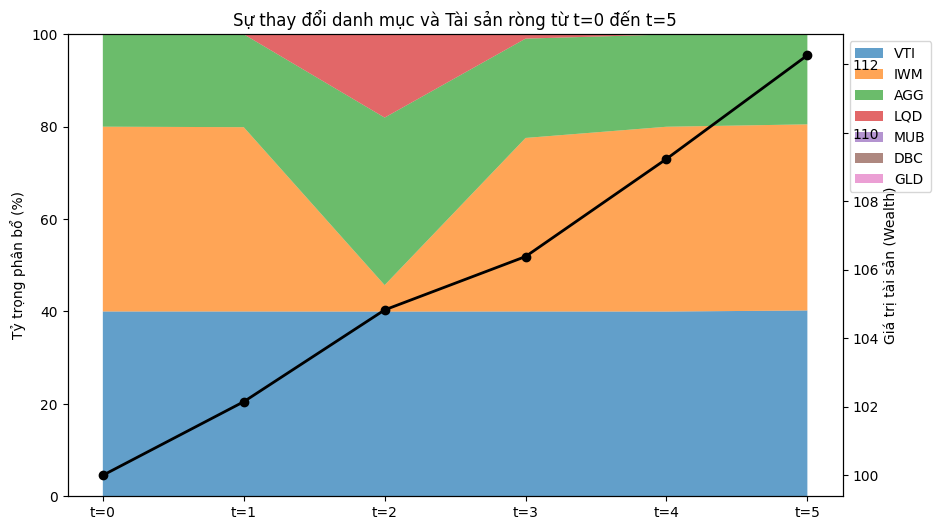

In [56]:
import matplotlib.pyplot as plt

def display_time_series_process(result_dict, tickers, scenario_idx=0):
    if "x_values" not in result_dict:
        print("Lỗi: Dữ liệu chuỗi thời gian không tồn tại trong kết quả.")
        return

    # Trích xuất dữ liệu cho một kịch bản cụ thể (mặc định kịch bản số 0)
    # x_values là list chứa T+1 mảng, mỗi mảng có kích thước (S, N)
    T = len(result_dict["x_values"]) - 1
    
    time_data = []
    for t in range(T + 1):
        wealth_at_t = result_dict["x_values"][t][scenario_idx]
        total_w = np.sum(wealth_at_t)
        row = {"Giai đoạn": f"t={t}", "Tổng tài sản": total_w}
        for i, ticker in enumerate(tickers):
            row[ticker] = wealth_at_t[i]
        time_data.append(row)

    df_time = pd.DataFrame(time_data)
    
    print("\n" + "="*80)
    print(f"QUY TRÌNH BIẾN ĐỘNG THEO THỜI GIAN - KỊCH BẢN #{scenario_idx}")
    print("="*80)
    print(df_time.to_string(index=False))
    
    # --- VẼ BIỂU ĐỒ MINH HỌA ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Vẽ biểu đồ diện tích chồng (Stacked Area Chart) cho tỷ trọng
    weights = df_time[tickers].div(df_time["Tổng tài sản"], axis=0) * 100
    ax1.stackplot(df_time["Giai đoạn"], weights.T, labels=tickers, alpha=0.7)
    ax1.set_ylabel("Tỷ trọng phân bổ (%)")
    ax1.set_ylim(0, 100)
    ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Vẽ đường tổng tài sản
    ax2 = ax1.twinx()
    ax2.plot(df_time["Giai đoạn"], df_time["Tổng tài sản"], color='black', marker='o', linewidth=2, label="Tổng tài sản")
    ax2.set_ylabel("Giá trị tài sản (Wealth)")
    
    plt.title(f"Sự thay đổi danh mục và Tài sản ròng từ t=0 đến t={T}")
    plt.show()

# Hiển thị thử cho kịch bản Base Case
display_time_series_process(res_bull, tickers, scenario_idx=3) # Xem kịch bản thứ k

## 9. RESULT

### Two-stage

In [66]:
import numpy as np

# 1. Chuyển list thành numpy array (nếu chưa chuyển)
scenario_returns_np = np.array(scenario_returns) 

# 2. Cắt lấy giai đoạn đầu tiên (T=1)
scenario_returns_2s = scenario_returns_np[:, :1, :] 

# 3. QUAN TRỌNG: Lọc lại dictionary 'nodes' để chỉ lấy t=0 và t=1
# Điều này giúp hàm không truy cập vào các index x[2], x[3]... vượt quá phạm vi của mô hình 2 giai đoạn
nodes_2stage = {k: v for k, v in nodes.items() if k[0] <= 1}

# 4. Chạy mô hình 2 giai đoạn với bộ nodes đã lọc
res_two_stage = solve_multistage_cvar(
    scenario_returns_2s, 
    scenario_probs, 
    nodes_2stage, # Dùng nodes đã lọc ở đây
    initial_wealth=100.0, 
    lambda_cvar=0.5
)

if res_two_stage["status"] in ["optimal", "optimal_inaccurate"]:
    print(f"Trạng thái mô hình 2 giai đoạn: {res_two_stage['status'].upper()}")
else:
    print("Mô hình 2 giai đoạn không tìm thấy nghiệm tối ưu.")

Trạng thái mô hình 2 giai đoạn: OPTIMAL


### Table

In [69]:
import numpy as np
import pandas as pd

def get_full_metrics(result, name, initial_wealth=100.0):
    """
    Hàm tính toán các chỉ số: LN, Volatility, Sharpe, CVaR 5%, Max Drawdown
    Dựa trên thiết kế thí nghiệm yêu cầu.
    """
    # Kiểm tra tính hợp lệ của kết quả đầu vào
    if not result or "status" not in result or result["status"] not in ["optimal", "optimal_inaccurate"]:
        return [name, "N/A", "N/A", "N/A", "N/A", "N/A"]

    # 1. Lợi nhuận kỳ vọng (%)
    ret = result.get("exp_return_pct", 0)
    
    # 2. Giá trị tài sản cuối kỳ của các kịch bản
    # Lưu ý: x_values[T] có shape (S, N)
    final_wealths = np.sum(result["x_values"][-1], axis=1)
    
    # 3. Volatility (Độ biến động giữa các kịch bản)
    vol = np.std(final_wealths / initial_wealth)
    
    # 4. Sharpe Ratio (Giả định lãi suất phi rủi ro = 0)
    sharpe = (ret / 100) / vol if vol != 0 else 0
    
    # 5. CVaR (Đã có trong kết quả tối ưu của model)
    cvar5 = result.get("cvar", 0)
    
    # 6. Max Drawdown (Mức lỗ lớn nhất so với vốn ban đầu)
    max_dd = (np.min(final_wealths) - initial_wealth) / initial_wealth * 100
    
    return [name, f"{ret:.2f}%", f"{vol:.4f}", f"{sharpe:.4f}", f"{cvar5:.2f}", f"{max_dd:.2f}%"]

# --- TỔNG HỢP DỮ LIỆU ---
data_summary = []

# Thêm Markowitz (Baseline 1) - Nếu bạn đã chạy res_mv
if 'res_mv' in locals():
    data_summary.append(get_full_metrics(res_mv, "Markowitz (Static)"))

# Thêm Two-stage (Baseline 2)
if 'res_two_stage' in locals():
    data_summary.append(get_full_metrics(res_two_stage, "Two-stage"))

# Thêm Multi-stage (Đề xuất)
if 'res_base' in locals():
    data_summary.append(get_full_metrics(res_base, "Multi-stage (MS-MILP)"))

# Tạo DataFrame
df_final_compare = pd.DataFrame(data_summary, columns=["Mô hình", "Tổng LN", "Volatility", "Sharpe", "CVaR 5%", "Max Drawdown"])

# Hiển thị bảng
print("\n" + "="*85)
print(f"{'KẾT QUẢ SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH':^85}")
print("="*85)
print(df_final_compare.to_string(index=False))
print("="*85)


                        KẾT QUẢ SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH                        
              Mô hình Tổng LN Volatility  Sharpe CVaR 5% Max Drawdown
            Two-stage  -0.14%     0.0150 -0.0911   13.90       -4.96%
Multi-stage (MS-MILP)  -5.50%     0.0604 -0.9099   29.32      -22.46%


### Statistical Test

In [74]:
from scipy import stats

wealth_ms = np.sum(res_base["x_values"][-1], axis=1)
wealth_mv = 100 * (1 + (compute_terminal_returns(scenario_returns) @ res_mv["weights"]))

t_stat, p_value = stats.ttest_rel(wealth_ms, wealth_mv)

print(f"\nKiểm định Paired T-test:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa mô hình đề xuất và Markowitz.")
else:
    print("Kết luận: Chưa đủ bằng chứng thống kê về sự khác biệt.")

AttributeError: 'list' object has no attribute 'shape'

## 10. Benchmark

### Equal Weight

In [85]:
import numpy as np
import pandas as pd

# ===================================
# Equal Weight benchmark
# ===================================

returns_df = returns.copy()

tickers = returns_df.columns.tolist()

ew_R = returns_df.values

n_assets = len(tickers)

ew_weights = np.ones(
    n_assets
) / n_assets


ew_weights_df = pd.DataFrame({

    "Asset": tickers,
    "Weight": ew_weights
})

print(
    "=== Equal Weight Portfolio ==="
)

print(
    ew_weights_df
)


# Portfolio returns
ew_portfolio_returns = (
    ew_R @ ew_weights
)


# Metrics
ew_expected_return = (
    ew_portfolio_returns.mean()
    *252
)

ew_volatility = (
    ew_portfolio_returns.std()
    *np.sqrt(252)
)

ew_sharpe = (
    ew_expected_return
    /
    ew_volatility
)


# Wealth
ew_wealth = np.cumprod(
    1+ew_portfolio_returns
)

# Drawdown
ew_peak = np.maximum.accumulate(
    ew_wealth
)

ew_drawdown = (
    ew_wealth-ew_peak
)/ew_peak

ew_max_drawdown = (
    ew_drawdown.min()
)


# VaR/CVaR
alpha=0.95

ew_var95=np.quantile(
    ew_portfolio_returns,
    1-alpha
)

ew_cvar95=ew_portfolio_returns[
    ew_portfolio_returns
    <=ew_var95
].mean()


print(
    "\n===== Equal Weight Metrics ====="
)

print(
    f"Expected Return: {ew_expected_return:.4%}"
)

print(
    f"Volatility: {ew_volatility:.4%}"
)

print(
    f"Sharpe Ratio: {ew_sharpe:.4f}"
)

print(
    f"VaR(95%): {ew_var95:.4%}"
)

print(
    f"CVaR(95%): {ew_cvar95:.4%}"
)

print(
    f"Max Drawdown: {ew_max_drawdown:.4%}"
)

=== Equal Weight Portfolio ===
  Asset    Weight
0   VTI  0.142857
1   IWM  0.142857
2   AGG  0.142857
3   LQD  0.142857
4   MUB  0.142857
5   DBC  0.142857
6   GLD  0.142857

===== Equal Weight Metrics =====
Expected Return: 5.0305%
Volatility: 8.3820%
Sharpe Ratio: 0.6002
VaR(95%): -0.7777%
CVaR(95%): -1.2489%
Max Drawdown: -21.7290%


### Mean-Variance

In [118]:
import cvxpy as cp
import numpy as np
import pandas as pd

# ===================================
# Mean-Variance benchmark
# ===================================

returns_df = returns.copy()

tickers = returns_df.columns.tolist()

mv_R = returns_df.values

mv_mu = mv_R.mean(axis=0)

mv_cov = np.cov(
    mv_R,
    rowvar=False
)

n_assets = len(tickers)

risk_aversion = 10
u_bound = 0.40


mv_w = cp.Variable(
    n_assets,
    nonneg=True
)


mv_objective = cp.Maximize(

    mv_mu @ mv_w

    -

    risk_aversion
    *
    cp.quad_form(
        mv_w,
        mv_cov
    )
)


mv_constraints=[

    cp.sum(mv_w)==1,

    mv_w<=u_bound
]


mv_problem=cp.Problem(
    mv_objective,
    mv_constraints
)

mv_problem.solve()

print(
    "Status:",
    mv_problem.status
)

mv_weights=mv_w.value

Status: optimal


### Single-stage CVaR

In [119]:
import cvxpy as cp
import numpy as np
import pandas as pd

# ===================================
# Single-stage CVaR benchmark
# ===================================

returns_df = returns.copy()

tickers = returns_df.columns.tolist()

R = np.array(scenario_returns)

S, T, N = R.shape

# Gộp lợi nhuận toàn bộ các giai đoạn
# (single-stage dùng expected one-shot distribution)
scenario_terminal = np.mean(
    R,
    axis=1
)

scenario_probs_ss = scenario_probs.copy()


# Parameters
lambda_cvar = 0.5
alpha = 0.95

M = 4
l_bound = 0.05
u_bound = 0.40


# Variables
ss_w = cp.Variable(
    N,
    nonneg=True
)

ss_z = cp.Variable(
    N,
    boolean=True
)

ss_zeta = cp.Variable()

ss_xi = cp.Variable(
    S,
    nonneg=True
)


# Scenario portfolio returns
portfolio_returns = (

    scenario_terminal
    @
    ss_w
)

loss = -portfolio_returns


# Expected return
expected_return = (

    scenario_probs_ss
    @
    portfolio_returns
)


# CVaR
cvar = (

    ss_zeta
    +

    (1/(1-alpha))

    *

    (
        scenario_probs_ss
        @
        ss_xi
    )
)


# Objective
objective = cp.Maximize(

    expected_return

    -

    lambda_cvar*cvar
)


# Constraints
constraints=[

    cp.sum(ss_w)==1,

    ss_w>=l_bound*ss_z,

    ss_w<=u_bound*ss_z,

    cp.sum(ss_z)<=M,

    ss_xi>=(
        loss
        -
        ss_zeta
    )
]


problem=cp.Problem(
    objective,
    constraints
)

problem.solve(
    solver=cp.GLPK_MI
)


print(
    "Status:",
    problem.status
)


# Weights
ss_weights=ss_w.value

ss_df=pd.DataFrame({

    "Asset":tickers,
    "Weight":ss_weights
})

print(
    "\n=== Single-CVaR Portfolio ==="
)

print(
    ss_df.round(4)
)


# ===================================
# Historical evaluation
# ===================================

hist_R = returns_df.values

ss_portfolio_returns=(
    hist_R
    @
    ss_weights
)


ss_expected_return=(
    ss_portfolio_returns.mean()
    *
    252
)

ss_volatility=(
    ss_portfolio_returns.std()
    *
    np.sqrt(252)
)

ss_sharpe=(
    ss_expected_return
    /
    ss_volatility
)


wealth=np.cumprod(
    1+ss_portfolio_returns
)

peak=np.maximum.accumulate(
    wealth
)

drawdown=(
    wealth-peak
)/peak

ss_max_drawdown=drawdown.min()


var95=np.quantile(
    ss_portfolio_returns,
    0.05
)

ss_cvar95=ss_portfolio_returns[
    ss_portfolio_returns<=var95
].mean()


print(
    "\n===== Single-CVaR Metrics ====="
)

print(
    f"Expected Return: {ss_expected_return:.4%}"
)

print(
    f"Sharpe Ratio: {ss_sharpe:.4f}"
)

print(
    f"CVaR(95%): {ss_cvar95:.4%}"
)

print(
    f"Max Drawdown: {ss_max_drawdown:.4%}"
)

Status: optimal

=== Single-CVaR Portfolio ===
  Asset  Weight
0   VTI     0.0
1   IWM     0.0
2   AGG     0.4
3   LQD     0.4
4   MUB     0.2
5   DBC     0.0
6   GLD     0.0

===== Single-CVaR Metrics =====
Expected Return: 2.9282%
Sharpe Ratio: 0.5363
CVaR(95%): -0.7923%
Max Drawdown: -19.7873%


### MS-CVaR

In [124]:
# ===================================
# Multi-stage CVaR benchmark
# ===================================

ms_result = solve_multistage_cvar(
    scenario_returns=scenario_returns,
    scenario_probs=scenario_probs,
    nodes=nodes,

    initial_wealth=100,
    lambda_cvar=0.5,
    alpha=0.95,

    tc_cost=0.002,
    M=4,
    l_bound=0.05,
    u_bound=0.40,
    W_target=110
)

print(
    "Status:",
    ms_result["status"]
)


# ===================================
# Initial allocation
# ===================================

tickers = returns.columns.tolist()

ms_weights = (
    ms_result["x_t0"]
    /
    np.sum(
        ms_result["x_t0"]
    )
)

ms_weights_df = pd.DataFrame({

    "Asset":tickers,
    "Weight":ms_weights
})

print(
    "\n=== MS-CVaR Portfolio ==="
)

print(
    ms_weights_df
)


# ===================================
# Metrics
# ===================================

# Return (%)
ms_expected_return = (
    ms_result["exp_return_pct"]
)

# Wealth loss → return loss
initial_wealth = 100

ms_cvar = (
    -ms_result["cvar"]
    / initial_wealth
)

ms_var = (
    -ms_result["var"]
    / initial_wealth
)

ms_var = (
    ms_result[
        "var"
    ]
)


# Approximate portfolio series
# dùng historical return để tính Sharpe/Drawdown

R = returns.values

ms_portfolio_returns = (
    R
    @
    ms_weights
)

ms_volatility = (

    ms_portfolio_returns.std()
    *
    np.sqrt(252)
)

ms_sharpe = (

    (ms_portfolio_returns.mean()*252)
    /
    ms_volatility
)


# Wealth curve
ms_wealth = np.cumprod(
    1+ms_portfolio_returns
)

ms_peak = np.maximum.accumulate(
    ms_wealth
)

ms_drawdown = (
    ms_wealth
    -
    ms_peak
)/ms_peak

ms_max_drawdown = (
    ms_drawdown.min()
)


print(
    "\n===== MS-CVaR Metrics ====="
)

print(
    f"Expected Return: {ms_expected_return:.4f}%"
)

print(
    f"VaR: {ms_var:.4f}"
)

print(
    f"CVaR: {ms_cvar:.4f}"
)

print(
    f"Sharpe Ratio: {ms_sharpe:.4f}"
)

print(
    f"Max Drawdown: {ms_max_drawdown:.4%}"
)

Status: optimal

=== MS-CVaR Portfolio ===
  Asset    Weight
0   VTI  0.000000
1   IWM  0.000000
2   AGG  0.400000
3   LQD  0.399931
4   MUB  0.200069
5   DBC  0.000000
6   GLD  0.000000

===== MS-CVaR Metrics =====
Expected Return: -5.9204%
VaR: 18.4831
CVaR: -0.2209
Sharpe Ratio: 0.5363
Max Drawdown: -19.7864%


In [126]:
import numpy as np
import pandas as pd

# ===================================
# Bull Market Scenario
# ===================================

scenario_returns_bull = np.copy(
    scenario_returns
)

# VTI
scenario_returns_bull[:, :, 0] += 0.03

# IWM
scenario_returns_bull[:, :, 1] += 0.03

# AGG
scenario_returns_bull[:, :, 2] += 0.005

# LQD
scenario_returns_bull[:, :, 3] += 0.005

# MUB
scenario_returns_bull[:, :, 4] += 0.005

# DBC
scenario_returns_bull[:, :, 5] += 0.01

# GLD
scenario_returns_bull[:, :, 6] += 0.01


print("===== Mean Scenario Return =====")

print(
    scenario_returns_bull.mean(
        axis=(0,1)
    )
)

print(
    "\nRunning MS-CVaR..."
)

res_bull = solve_multistage_cvar(

    scenario_returns=scenario_returns_bull,

    scenario_probs=scenario_probs,

    nodes=nodes,

    lambda_cvar=0.1,
    alpha=0.95,

    tc_cost=0.002,

    M=4,
    l_bound=0.05,
    u_bound=0.40,

    initial_wealth=100,
    W_target=110
)


print(
    "\nStatus:",
    res_bull["status"]
)


# Allocation
tickers = returns.columns.tolist()

bull_df = pd.DataFrame({

    "Asset": tickers,

    "Value": res_bull["x_t0"]
})


bull_df["Weight"] = (

    bull_df["Value"]

    /

    bull_df["Value"].sum()
)


print(
    "\n===== Initial Allocation ====="
)

print(
    bull_df.round(4)
)


print(
    "\n===== Metrics ====="
)

print(
    f"Expected Wealth: {res_bull['expected_wealth']:.4f}"
)

print(
    f"Expected Return: {res_bull['exp_return_pct']:.4f}%"
)

print(
    f"VaR: {res_bull['var']:.4f}"
)

print(
    f"CVaR: {res_bull['cvar']:.4f}"
)

===== Mean Scenario Return =====
[-0.00286959 -0.00902244 -0.00624379 -0.00904282 -0.01250365 -0.01276327
 -0.01529386]

Running MS-CVaR...

Status: optimal

===== Initial Allocation =====
  Asset  Value  Weight
0   VTI   40.0     0.4
1   IWM   40.0     0.4
2   AGG   20.0     0.2
3   LQD    0.0     0.0
4   MUB    0.0     0.0
5   DBC    0.0     0.0
6   GLD    0.0     0.0

===== Metrics =====
Expected Wealth: 100.4279
Expected Return: 0.4279%
VaR: 23.9576
CVaR: 27.3051


### TABLE

In [125]:
benchmark = pd.DataFrame({

    "Model":[
        "Equal Weight",
        "Mean Variance",
        "Single CVaR",
        "MS-CVaR"
    ],

    "Expected Return":[

        ew_expected_return,
        mv_expected_return,
        ss_expected_return,
        ms_expected_return/100
    ],

    "CVaR":[

        ew_cvar95,
        mv_cvar95,
        ss_cvar95,
        ms_cvar
    ],

    "Sharpe":[

        ew_sharpe,
        mv_sharpe,
        ss_sharpe,
        ms_sharpe
    ],

    "MaxDD":[

        ew_max_drawdown,
        mv_max_drawdown,
        ss_max_drawdown,
        ms_max_drawdown
    ]
})

print(
    benchmark.round(4)
)

           Model  Expected Return    CVaR  Sharpe   MaxDD
0   Equal Weight           0.0503 -0.0125  0.6002 -0.2173
1  Mean Variance           0.0453 -0.0074  0.8840 -0.1584
2    Single CVaR           0.0293 -0.0079  0.5363 -0.1979
3        MS-CVaR          -0.0592 -0.2209  0.5363 -0.1979
